# MovieLens 100K: Predicting Ratings to Power a Movie Recommender

**PhDAI 732: Fundamentals of AI-Enabled Systems. Group Project**
University of the Cumberlands · Dr. Manjunath Paramashivaiah

**Team:** Manoj Kashyap Ranganath · Onyebuchi Asogwa · Blake Mires (dataset exploration &
preprocessing) · Jose M. Santiago Echevarria (model development & evaluation)

---

This notebook runs top to bottom in Google Colab or on a local machine. It downloads the
MovieLens 100K dataset, cleans and explores it, then develops and evaluates an initial set
of collaborative-filtering models for predicting how a user will rate a movie they have not
seen.

## § 0. Problem framing

**The business problem.** A subscription streaming service earns nothing from a catalog a
subscriber never opens. With thousands of titles and a subscriber who will browse for a
minute or two before giving up, the scarce resource is not content but *attention*: the ten
slots on the home screen. The question the business actually needs answered is "which ten of
our titles is *this* subscriber most likely to enjoy?", and answering it well is what turns
a large catalog into retained subscriptions.

**The analytics problem.** We cannot observe enjoyment, but we can observe ratings. So we
restate the business question as a supervised learning problem: given a history of
user-movie ratings, **predict the rating a user would give a movie they have not yet rated**.
The target is a number from 1 to 5, so this is a **regression** task, and we measure it with
Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). Once we can score every unseen
movie for every user, ranking those scores produces the top-ten list the business asked for,
which we check separately with precision@10 and catalog coverage.

**Why this is not ordinary regression.** There is no feature matrix here. We have a
943 by 1,682 grid of ratings that is roughly 94% empty, and the only signal available is the
pattern of who rated what. Predictions therefore have to be borrowed from *other* users and
*other* movies, the family of methods called **collaborative filtering**.

**Stakeholders and what each one needs.** Subscribers need recommendations that are relevant
and varied rather than the same blockbusters everyone already knows. The content team needs
the long tail of the catalog to be reachable, or the licensing spend on niche titles is
wasted. The business needs an honest estimate of accuracy before anything is put in front of
a customer. These three interests do not automatically agree, and § 8 and § 9 show
concretely where they pull apart.

## § 0.1. Environment and reproducibility

Every number in the report comes from one executed run of this notebook. The cell below
pins the seed and prints the exact library versions used, so the run can be reproduced.

In [1]:
import os

# Set before NumPy is imported. On this Apple-silicon build NumPy's Accelerate
# BLAS raises spurious divide/overflow/invalid flags during large matmuls; the
# results are unaffected, but the warnings would bury the notebook's output.
os.environ["PYTHONWARNINGS"] = "ignore"

import platform
import sys
import urllib.request
import warnings
import zipfile

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold, train_test_split

warnings.filterwarnings("ignore")
np.seterr(all="ignore")

SEED = 42
np.random.seed(SEED)

# Colab keeps working files in /content; locally we use the notebook's folder.
BASE_DIR = "/content" if os.path.isdir("/content") else "."
DATA_DIR = os.path.join(BASE_DIR, "ml-100k")
ZIP_PATH = os.path.join(BASE_DIR, "ml-100k.zip")
IMG_DIR = os.path.join(".", "images", "recommender")
os.makedirs(IMG_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})
BLUE, GREY, ORANGE = "#2c6fbb", "#9aa5b1", "#e07b39"

print("Python     ", sys.version.split()[0])
print("NumPy      ", np.__version__)
print("pandas     ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib ", matplotlib.__version__)
print("platform   ", platform.platform())
print("seed       ", SEED)
print("data dir   ", DATA_DIR)

Python      3.9.6
NumPy       2.0.2
pandas      2.3.3
scikit-learn 1.6.1
matplotlib  3.9.4
platform    macOS-26.4.1-arm64-arm-64bit
seed        42
data dir    ./ml-100k


---

# Part 1. Dataset exploration and preprocessing

*Prepared by Blake Mires.*

## § 1. Acquire the dataset

The dataset is downloaded from the official GroupLens website, so no data files need to be
committed to the repository.

In [2]:
# official MovieLens 100K dataset URL
dataset_url = (
    "https://files.grouplens.org/"
    "datasets/movielens/ml-100k.zip"
)

# download the dataset if it is not already available
if not os.path.exists(ZIP_PATH):
    print("Downloading the dataset...")
    urllib.request.urlretrieve(dataset_url, ZIP_PATH)
    print("Download complete.")
else:
    print("The ZIP file already exists.")

# extract the dataset if it has not already been extracted
if not os.path.exists(DATA_DIR):
    print("Extracting the dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_reference:
        zip_reference.extractall(BASE_DIR)
    print("Extraction complete.")
else:
    print("The dataset folder already exists.")

The ZIP file already exists.
The dataset folder already exists.


**Load the rating data**

According to the MovieLens README, the `u.data` file contains four fields in this order:
user ID, item ID, rating, and timestamp. The file does not contain column headings, so the
names are assigned when it is loaded. The values are separated by tabs, which is why
`sep="\t"` is used.

In [3]:
# column order provided by the MovieLens README
rating_columns = [
    "user_id",
    "item_id",
    "rating",
    "timestamp"
]

# load the ratings file into a pandas DataFrame
ratings = pd.read_csv(
    os.path.join(DATA_DIR, "u.data"),
    sep="\t",
    names=rating_columns
)

# show the first five rows
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


**Load the movie IDs and titles**

The `u.item` file contains information about the movies in the MovieLens dataset. Our group
only needs the movie identification number and the movie title for this part of the project.

In [4]:
# load only the item ID and movie title columns
movies = pd.read_csv(
    os.path.join(DATA_DIR, "u.item"),
    sep="|",
    names=["item_id", "title"],
    usecols=[0, 1],
    encoding="latin-1"
)

# show the first five movies
movies.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


## § 2. Examine the dataset

The two tables are inspected before cleaning. The ratings table contains the user-movie
interactions, including the user ID, item ID, rating, and timestamp. The movie table
contains the item ID and the corresponding movie title.

In [5]:
# show the number of rows and columns in the ratings table
print("Ratings dataset dimensions:", ratings.shape)

# display the first five rating records
display(ratings.head())

# show ratings column names, data types, and nonmissing counts
ratings.info()

Ratings dataset dimensions: (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [6]:
# show movie-table dimensions
print("\nMovie dataset dimensions:", movies.shape)

# show the first five movie records
display(movies.head())

# show movie column names, data types, and nonmissing counts
movies.info()


Movie dataset dimensions: (1682, 2)


,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   item_id  1682 non-null   int64 
 1   title    1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB


In [7]:
# show stats for numerical columns
# this helps find unusual values and gives an overview of the dataset.
ratings.describe()

,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [8]:
# count all rows in the ratings table
# the README expected results are 100,000 ratings, 943 users, and 1,682 movies.
print("Number of ratings:", len(ratings))

# count the number of different user IDs
print(
    "Number of users:",
    ratings["user_id"].nunique()
)

# count the number of different movie IDs
print(
    "Number of movies:",
    ratings["item_id"].nunique()
)

Number of ratings: 100000
Number of users: 943
Number of movies: 1682


## § 3. Check data quality

Rather than assume the dataset is clean because it is a well-known benchmark, each quality
claim is checked and printed.

In [9]:
# check for missing values
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movie information:")
print(movies.isnull().sum())

Missing values in ratings:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Missing values in movie information:
item_id    0
title      0
dtype: int64


In [10]:
# check for duplicate records
print(
    "Duplicate rating rows:",
    ratings.duplicated().sum()
)

print(
    "Duplicate movie rows:",
    movies.duplicated().sum()
)

# count repeated item IDs in the movie table
print(
    "Duplicate movie IDs:",
    movies.duplicated(
        subset=["item_id"]
    ).sum()
)

Duplicate rating rows: 0
Duplicate movie rows: 0
Duplicate movie IDs: 0


In [11]:
# a user should not be able to rate the same movie twice
duplicate_pairs = ratings.duplicated(
    subset=["user_id", "item_id"]
).sum()

print("Repeated user-movie pairs:", duplicate_pairs)

Repeated user-movie pairs: 0


**Check the data types and rating values**

The project instructions state that user IDs should be integers, item IDs should be
integers, and ratings should be floats.

In [12]:
print("Ratings data types:")
print(ratings.dtypes)

print("\nMovie data types:")
print(movies.dtypes)

Ratings data types:
user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

Movie data types:
item_id     int64
title      object
dtype: object


In [13]:
# rating values
# MovieLens ratings should range from 1 through 5.
print(
    "Rating values:",
    sorted(int(v) for v in ratings["rating"].unique())
)

Rating values: [1, 2, 3, 4, 5]


## § 4. Clean and format the data

The checks above found no missing values, no duplicate rows, and no out-of-range ratings, so
the cleaning steps below remove nothing. They are kept deliberately: they document the
standard the data had to meet, and they make the notebook safe to re-run against a future
MovieLens extract that may be less tidy.

In [14]:
# create copies and clean the tables
ratings_clean = ratings.copy()
movies_clean = movies.copy()

# remove rating rows containing missing values
ratings_clean = ratings_clean.dropna()

# remove movie rows missing an item ID or title
movies_clean = movies_clean.dropna(
    subset=["item_id", "title"]
)

# remove completely duplicated rating records
ratings_clean = ratings_clean.drop_duplicates()

# keep the first movie record for each item ID
movies_clean = movies_clean.drop_duplicates(
    subset=["item_id"],
    keep="first"
)

In [15]:
# confirm the data types and convert ratings
print("Ratings data types before conversion:")
print(ratings_clean.dtypes)

print("\nMovie data types:")
print(movies_clean.dtypes)

# convert only the rating column from integers to floats
ratings_clean["rating"] = (
    ratings_clean["rating"].astype(float)
)

print("\nFinal ratings data types:")
print(ratings_clean.dtypes)

Ratings data types before conversion:
user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

Movie data types:
item_id     int64
title      object
dtype: object

Final ratings data types:
user_id        int64
item_id        int64
rating       float64
timestamp      int64
dtype: object


In [16]:
# compare data before and after cleaning
print(
    "Original rating rows:",
    len(ratings)
)

print(
    "Clean rating rows:",
    len(ratings_clean)
)

print(
    "Rating rows removed:",
    len(ratings) - len(ratings_clean)
)

Original rating rows: 100000
Clean rating rows: 100000
Rating rows removed: 0


In [17]:
# merge ratings and movie titles
data = ratings_clean.merge(
    movies_clean,
    on="item_id",
    how="left"
)

# show the first five combined records
data.head()

,user_id,item_id,rating,timestamp,title
0,196,242,3.0,881250949,Kolya (1996)
1,186,302,3.0,891717742,L.A. Confidential (1997)
2,22,377,1.0,878887116,Heavyweights (1994)
3,244,51,2.0,880606923,Legends of the Fall (1994)
4,166,346,1.0,886397596,Jackie Brown (1997)


In [18]:
# check the combined dataset
print("Combined columns:")
print(data.columns.tolist())

# count records that did not receive a movie title
print(
    "\nRatings without a movie title:",
    data["title"].isnull().sum()
)

data.info()

Combined columns:
['user_id', 'item_id', 'rating', 'timestamp', 'title']

Ratings without a movie title: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   user_id    100000 non-null  int64  
 1   item_id    100000 non-null  int64  
 2   rating     100000 non-null  float64
 3   timestamp  100000 non-null  int64  
 4   title      100000 non-null  object 
dtypes: float64(1), int64(3), object(1)
memory usage: 3.8+ MB


## § 5. Exploratory data analysis

Three questions drive the exploration, and each one turns out to constrain the modeling
that follows: how are the ratings themselves distributed, how much does each user
contribute, and how much attention does each movie receive?

Number of times each rating was given:
rating
1.0     6110
2.0    11370
3.0    27145
4.0    34174
5.0    21201
Name: count, dtype: int64

Mean rating: 3.5299
Share of ratings that are 4 or 5: 0.5538


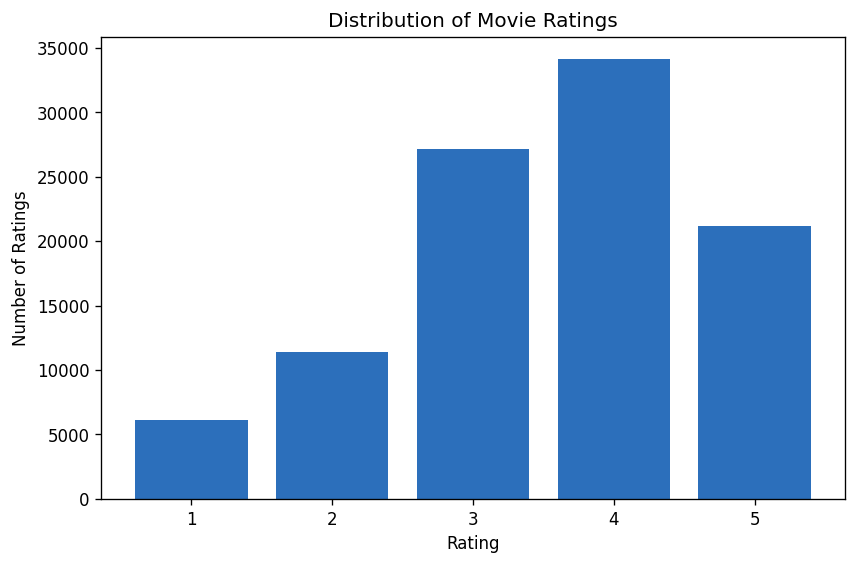

In [19]:
# visualize the distribution of ratings
rating_counts = (
    data["rating"]
    .value_counts()
    .sort_index()
)

print("Number of times each rating was given:")
print(rating_counts)
print("\nMean rating:", round(data["rating"].mean(), 4))
print("Share of ratings that are 4 or 5:",
      round((data["rating"] >= 4).mean(), 4))

plt.figure(figsize=(8, 5))
plt.bar(
    rating_counts.index,
    rating_counts.values,
    color=BLUE
)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks([1, 2, 3, 4, 5])
plt.show()

**Bar chart results**

Most ratings were positive. A 4 was the most common, followed by 3 and then 5. Ratings of 1
and 2 were less frequent, so users generally rated the movies favorably. The mean rating sits
well above the midpoint of the scale, which matters for modeling: a model that simply
predicts a high number for everything will already look deceptively good, so any model we
build has to be compared against exactly that trivial baseline.

Summary of ratings submitted per user:
count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64


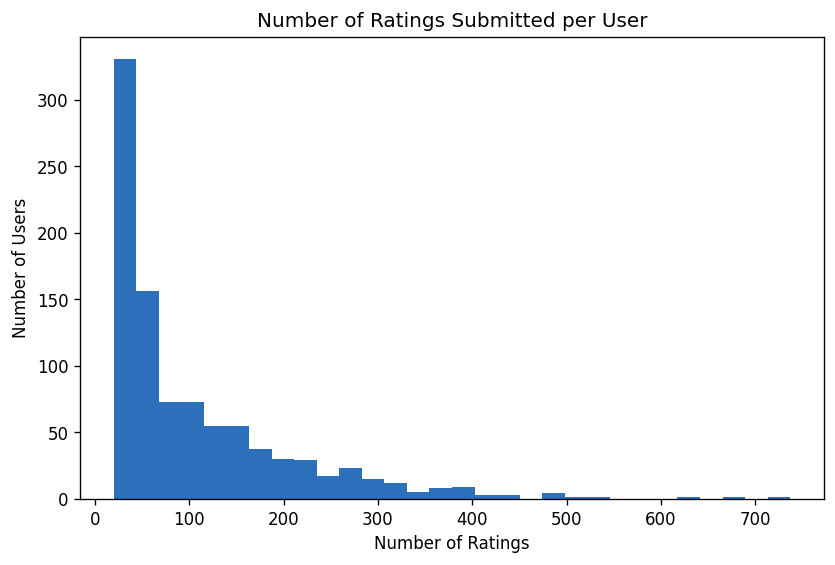

In [20]:
# visualize the number of ratings submitted per user
ratings_per_user = (
    data
    .groupby("user_id")
    .size()
)

print("Summary of ratings submitted per user:")
print(ratings_per_user.describe())

plt.figure(figsize=(8, 5))
plt.hist(
    ratings_per_user,
    bins=30,
    color=BLUE
)
plt.title("Number of Ratings Submitted per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

**Histogram per user results**

The x-axis shows the number of ratings submitted and the y-axis shows how many users fall
within each range. The chart shows that most users did not submit a lot of reviews, but a
small number of users submitted several hundred. This made a right-skewed distribution, with
a long tail extending toward the higher rating counts.

Summary of ratings received per movie:
count    1682.000000
mean       59.453032
std        80.383846
min         1.000000
25%         6.000000
50%        27.000000
75%        80.000000
max       583.000000
dtype: float64


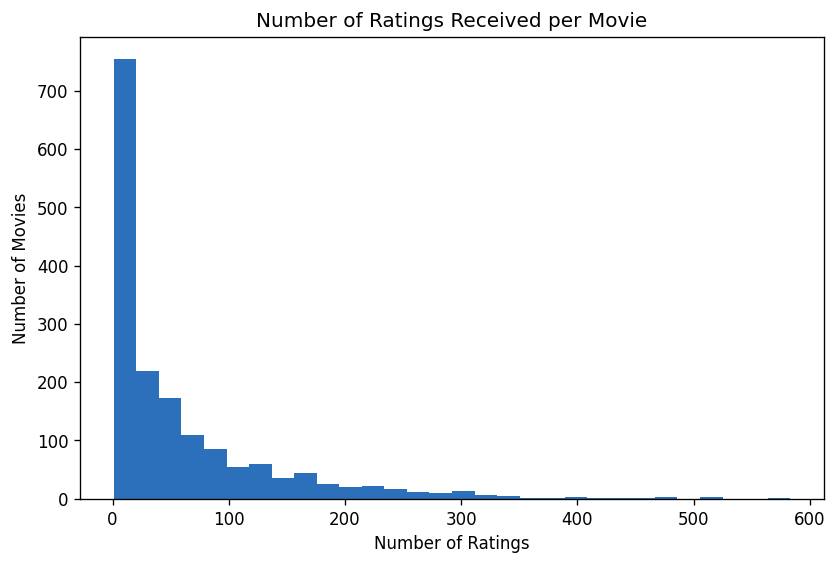

In [21]:
# group the records by movie and count each movie's ratings
ratings_per_movie = (
    data
    .groupby("item_id")
    .size()
)

print("Summary of ratings received per movie:")
print(ratings_per_movie.describe())

plt.figure(figsize=(8, 5))
plt.hist(
    ratings_per_movie,
    bins=30,
    color=BLUE
)
plt.title("Number of Ratings Received per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

**Histogram of ratings per movie results**

Most movies only got a few ratings, while a small number received several hundred. This made
another right-skewed distribution with a long tail toward the most frequently rated movies.

In [22]:
# movie-rating summary
movie_summary = (
    data
    .groupby(
        ["item_id", "title"],
        as_index=False
    )
    .agg(
        # count the number of ratings received by each movie
        number_of_ratings=("rating", "count"),

        # calculate the average rating for each movie
        average_rating=("rating", "mean")
    )
)

# round each average rating to two decimal places
movie_summary["average_rating"] = (
    movie_summary["average_rating"].round(2)
)

movie_summary.head()

,item_id,title,number_of_ratings,average_rating
0,1,Toy Story (1995),452,3.88
1,2,GoldenEye (1995),131,3.21
2,3,Four Rooms (1995),90,3.03
3,4,Get Shorty (1995),209,3.55
4,5,Copycat (1995),86,3.30


In [23]:
# show the most frequently rated movies
most_rated_movies = (
    movie_summary
    .sort_values(
        "number_of_ratings",
        ascending=False
    )
    .head(10)
)

most_rated_movies

,item_id,title,number_of_ratings,average_rating
49,50,Star Wars (1977),583,4.36
257,258,Contact (1997),509,3.80
99,100,Fargo (1996),508,4.16
180,181,Return of the Jedi (1983),507,4.01
293,294,Liar Liar (1997),485,3.16
285,286,"English Patient, The (1996)",481,3.66
287,288,Scream (1996),478,3.44
0,1,Toy Story (1995),452,3.88
299,300,Air Force One (1997),431,3.63
120,121,Independence Day (ID4) (1996),429,3.44


In [24]:
# show highly rated movies with at least 50 ratings
movies_with_50_ratings = movie_summary[
    movie_summary["number_of_ratings"] >= 50
]

highest_rated_movies = (
    movies_with_50_ratings
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(10)
)

highest_rated_movies

,item_id,title,number_of_ratings,average_rating
407,408,"Close Shave, A (1995)",112,4.49
317,318,Schindler's List (1993),298,4.47
168,169,"Wrong Trousers, The (1993)",118,4.47
482,483,Casablanca (1942),243,4.46
63,64,"Shawshank Redemption, The (1994)",283,4.45
113,114,Wallace & Gromit: The Best of Aardman Animatio...,67,4.45
602,603,Rear Window (1954),209,4.39
11,12,"Usual Suspects, The (1995)",267,4.39
49,50,Star Wars (1977),583,4.36
177,178,12 Angry Men (1957),125,4.34


Applying a minimum of 50 ratings before ranking by average score is itself a preprocessing
decision. Without it the leaderboard is captured by movies with a single 5-star rating,
which says more about one viewer than about the movie. The same reasoning reappears in the
models as *regularization*: an average computed from very little evidence should be pulled
back toward the overall mean.

## § 6. The shape of the problem: sparsity and the long tail

The two histograms above are the single most important fact about this dataset, so it is
worth quantifying rather than eyeballing. The models in Part 2 all have to work inside the
constraint this cell measures.

In [25]:
n_users = data["user_id"].nunique()
n_items = data["item_id"].nunique()
n_ratings = len(data)
n_cells = n_users * n_items
density = n_ratings / n_cells

print(f"users              {n_users:,}")
print(f"movies             {n_items:,}")
print(f"ratings observed   {n_ratings:,}")
print(f"cells in the matrix{n_cells:>12,}")
print(f"density            {density:.4%}")
print(f"sparsity           {1 - density:.4%}")

# how concentrated is attention?
counts = ratings_per_movie.sort_values(ascending=False)
for share in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(round(share * n_items)))
    print(f"top {share:>4.0%} of movies ({k:>4} titles) hold "
          f"{counts.head(k).sum() / n_ratings:>6.2%} of all ratings")

never_popular = (counts < 10).sum()
print(f"\nmovies with fewer than 10 ratings: {never_popular} "
      f"({never_popular / n_items:.1%} of the catalog)")
print(f"least-rated movie has {counts.min()} rating(s); "
      f"most-rated has {counts.max()}")

users              943
movies             1,682
ratings observed   100,000
cells in the matrix   1,586,126
density            6.3047%
sparsity           93.6953%
top   1% of movies (  17 titles) hold  7.63% of all ratings
top   5% of movies (  84 titles) hold 26.38% of all ratings
top  10% of movies ( 168 titles) hold 42.70% of all ratings
top  20% of movies ( 336 titles) hold 64.62% of all ratings

movies with fewer than 10 ratings: 530 (31.5% of the catalog)
least-rated movie has 1 rating(s); most-rated has 583


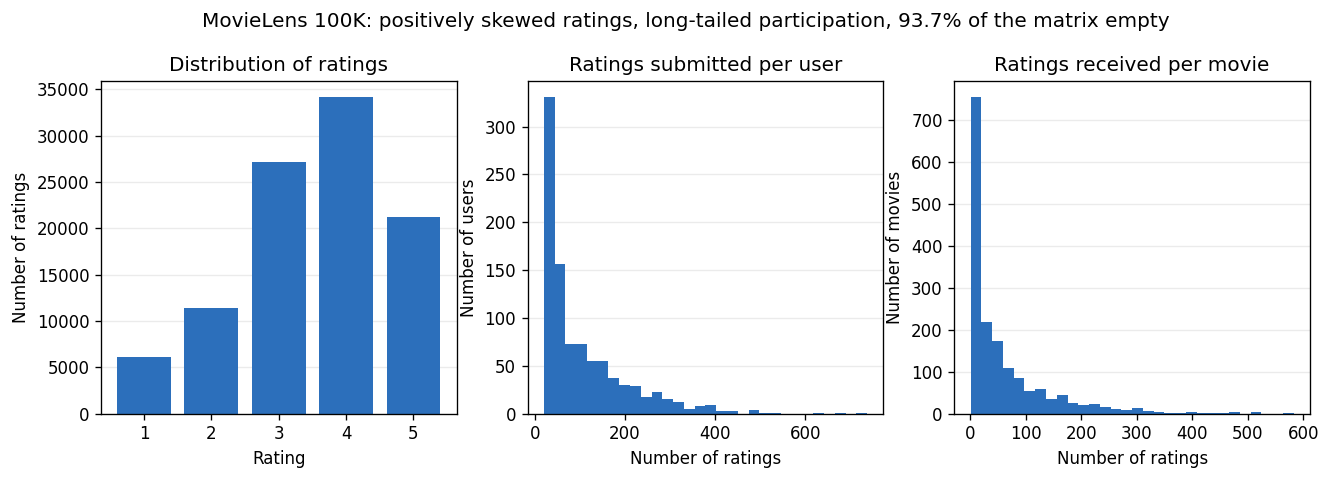

In [26]:
# one figure summarizing the data landscape, saved for the report
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

ax[0].bar(rating_counts.index, rating_counts.values, color=BLUE)
ax[0].set(title="Distribution of ratings", xlabel="Rating",
          ylabel="Number of ratings", xticks=[1, 2, 3, 4, 5])

ax[1].hist(ratings_per_user, bins=30, color=BLUE)
ax[1].set(title="Ratings submitted per user", xlabel="Number of ratings",
          ylabel="Number of users")

ax[2].hist(ratings_per_movie, bins=30, color=BLUE)
ax[2].set(title="Ratings received per movie", xlabel="Number of ratings",
          ylabel="Number of movies")

for a in ax:
    a.grid(axis="y", alpha=.25)
    a.set_axisbelow(True)

fig.suptitle(
    f"MovieLens 100K: positively skewed ratings, long-tailed participation, "
    f"{1 - density:.1%} of the matrix empty",
    y=1.04
)
fig.savefig(os.path.join(IMG_DIR, "data_landscape.png"))
plt.show()

## § 7. Prepare the data for modeling

Collaborative filtering needs only the three columns that describe *who rated what, and how
much*. The timestamp and the title are kept out of the model itself; the title is retained
separately so that recommendations can be read by a human, and the timestamp is left for
future work on how tastes drift over time.

The IDs are also converted to zero-based row and column indices, because the models operate
on a user by movie matrix rather than on the raw ID values.

In [27]:
# select the three columns required by the model
model_data = data[
    [
        "user_id",
        "item_id",
        "rating"
    ]
].copy()

# show the first five model-ready records
display(model_data.head())

# MovieLens IDs run 1..943 and 1..1682 with no gaps, so subtracting 1
# gives contiguous matrix indices.
user_index = model_data["user_id"].to_numpy() - 1
item_index = model_data["item_id"].to_numpy() - 1
rating_values = model_data["rating"].to_numpy(dtype=float)

print("\nuser index range:", user_index.min(), "to", user_index.max())
print("item index range:", item_index.min(), "to", item_index.max())
print("ratings:", rating_values.shape[0])

,user_id,item_id,rating
0,196,242,3.0
1,186,302,3.0
2,22,377,1.0
3,244,51,2.0
4,166,346,1.0



user index range: 0 to 942
item index range: 0 to 1681
ratings: 100000


---

# Part 2. Initial model development

*Prepared by Jose M. Santiago Echevarria.*

## § 8. The learning task and the evaluation protocol

**What is predicted.** For a user *u* and a movie *i*, predict the rating $\hat{r}_{ui}$ that
*u* would give *i*. Predictions are clipped to the valid $[1, 5]$ range, because a
prediction of 5.4 stars is not a stronger opinion, it is an error we can remove for free.

**How it is scored.** RMSE is the primary metric because large misses are what damage trust
in a recommender: telling someone they will love a film they hate is far worse than being
off by half a star. MAE is reported alongside it because it is in directly readable units:
"the typical prediction is off by *x* stars."

**How the data is split.** A single random 80/20 split would be wrong here in a specific
way: it could place *all* of a user's ratings in the test set, leaving nothing to learn that
user's taste from. The split is therefore **stratified by user**, so every user contributes
about 80% of their ratings to training and 20% to testing. Hyperparameters are chosen on a
**validation set carved out of the training data only**, and the test set is touched exactly
once, at the end. Nothing about the test set influences any modeling decision.

In [28]:
train_idx, test_idx = train_test_split(
    np.arange(n_ratings),
    test_size=0.2,
    random_state=SEED,
    stratify=user_index          # every user appears in both halves
)

u_train, i_train, r_train = (user_index[train_idx],
                             item_index[train_idx],
                             rating_values[train_idx])
u_test, i_test, r_test = (user_index[test_idx],
                          item_index[test_idx],
                          rating_values[test_idx])

print(f"training ratings {len(train_idx):,}")
print(f"test ratings     {len(test_idx):,}")
print(f"users present in training: {len(np.unique(u_train))} of {n_users}")

seen_items = np.unique(i_train)
cold_items = ~np.isin(i_test, seen_items)
print(f"\nmovies never seen during training: {n_items - len(seen_items)}")
print(f"test rows about an unseen movie:   {cold_items.sum()} "
      f"({cold_items.mean():.3%})")
print("Those rows are unavoidable cold starts; the models fall back to the")
print("global mean for them rather than silently failing.")

training ratings 80,000
test ratings     20,000
users present in training: 943 of 943

movies never seen during training: 26
test rows about an unseen movie:   28 (0.140%)
Those rows are unavoidable cold starts; the models fall back to the
global mean for them rather than silently failing.


In [29]:
# a validation split carved out of TRAINING data only, used for all tuning
sub_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=SEED,
    stratify=user_index[train_idx]
)

u_sub, i_sub, r_sub = (user_index[sub_idx], item_index[sub_idx],
                       rating_values[sub_idx])
u_val, i_val, r_val = (user_index[val_idx], item_index[val_idx],
                       rating_values[val_idx])

print(f"tuning subset {len(sub_idx):,} ratings")
print(f"validation    {len(val_idx):,} ratings")
print(f"held-out test {len(test_idx):,} ratings (untouched until the end)")

tuning subset 64,000 ratings
validation    16,000 ratings
held-out test 20,000 ratings (untouched until the end)


## § 9. The models

Four models are developed, chosen to span the standard families of collaborative filtering
and to escalate in sophistication so that each one's contribution can be isolated.

1. **Global mean.** Predicts the same number for everybody. The floor: any model that
   cannot beat this has learned nothing.
2. **Bias baseline.** $\hat{r}_{ui} = \mu + b_u + b_i$. Captures that some users rate
   generously and some movies are simply better, with no notion of personal taste at all.
   This is the honest baseline the personalized models must beat.
3. **Item-based k-NN collaborative filtering.** A neighborhood method: predict from the
   ratings this user gave to *similar* movies.
4. **Truncated SVD on a filled matrix.** Classical linear algebra, applied by first
   inventing a value for every missing cell.
5. **Biased matrix factorization (Funk-SVD).** Learns latent taste factors by gradient
   descent on the *observed* ratings only.

Models 4 and 5 are both "SVD" in the loose sense the recommender literature uses, and
comparing them directly is the point: they differ in whether the missing 94% of the matrix
is invented before factorizing or simply skipped.

In [30]:
RATING_MIN, RATING_MAX = 1.0, 5.0


def clip(predictions):
    """Ratings outside 1-5 are impossible, so clamp them."""
    return np.clip(predictions, RATING_MIN, RATING_MAX)


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

### 9.1. Bias baseline

Each bias is a *shrunk* average of the residual the other one leaves behind. The
regularization terms `reg_u` and `reg_i` act like phantom ratings at the global mean: a movie
with 400 ratings barely notices them, while a movie with two ratings is pulled most of the
way back to average. That is the formal version of the "at least 50 ratings" rule applied by
hand in § 5.

In [31]:
def fit_baseline(u, i, r, n_users, n_items, reg_u=5.0, reg_i=5.0, n_iter=20):
    """r_hat = mu + b_u + b_i, solved by alternating damped means (Koren, 2010)."""
    mu = float(np.mean(r))
    b_u = np.zeros(n_users)
    b_i = np.zeros(n_items)
    den_u = reg_u + np.bincount(u, minlength=n_users).astype(float)
    den_i = reg_i + np.bincount(i, minlength=n_items).astype(float)

    for _ in range(n_iter):
        residual = r - mu - b_u[u]
        num = np.bincount(i, weights=residual, minlength=n_items)
        # a movie absent from training has an undefined bias; 0 makes the
        # prediction fall back to the global mean instead of dividing by zero
        b_i = np.divide(num, den_i, out=np.zeros_like(num), where=den_i > 0)

        residual = r - mu - b_i[i]
        num = np.bincount(u, weights=residual, minlength=n_users)
        b_u = np.divide(num, den_u, out=np.zeros_like(num), where=den_u > 0)

    return mu, b_u, b_i


def predict_baseline(mu, b_u, b_i, u, i):
    return clip(mu + b_u[u] + b_i[i])

### 9.2. Item-based k-NN collaborative filtering

Similarity is measured between *movies* rather than users, because with 943 users and 1,682
movies each movie has more ratings to compare on, which makes the similarities steadier.

Two details matter. Similarity is computed on **baseline residuals**, not raw ratings, so
that two movies do not look alike merely because both are popular and both are rated by
generous users. And similarity is **shrunk** toward zero in proportion to how many users
actually rated both movies, so a single shared viewer cannot manufacture a perfect
correlation.

In [32]:
class ItemKNN:
    """Item-item neighborhood model on baseline-centered residuals."""

    def __init__(self, k=25, shrinkage=25.0, reg_u=5.0, reg_i=5.0):
        self.k = k
        self.shrinkage = shrinkage
        self.reg_u = reg_u
        self.reg_i = reg_i

    def fit(self, u, i, r, n_users, n_items):
        self.mu, self.b_u, self.b_i = fit_baseline(
            u, i, r, n_users, n_items, self.reg_u, self.reg_i
        )
        residual = r - (self.mu + self.b_u[u] + self.b_i[i])

        R = np.zeros((n_users, n_items))
        M = np.zeros((n_users, n_items))
        R[u, i] = residual
        M[u, i] = 1.0

        dot = R.T @ R                       # co-variance between movie columns
        norms = np.sqrt(np.diag(dot))
        denominator = np.outer(norms, norms)
        denominator[denominator == 0] = 1e-9
        sim = dot / denominator

        n_common = M.T @ M                  # users who rated both movies
        damp = n_common + self.shrinkage
        sim *= np.divide(n_common, damp, out=np.zeros_like(damp), where=damp > 0)
        np.fill_diagonal(sim, 0.0)
        self.sim = sim

        # per-user rated-movie lists, for fast lookup when predicting
        order = np.argsort(u, kind="stable")
        us, is_, rs = u[order], i[order], residual[order]
        bounds = np.searchsorted(us, np.arange(n_users + 1))
        self.user_items = [is_[bounds[a]:bounds[a + 1]] for a in range(n_users)]
        self.user_resid = [rs[bounds[a]:bounds[a + 1]] for a in range(n_users)]
        return self

    def predict(self, u, i):
        out = np.empty(len(u))
        for n, (uu, ii) in enumerate(zip(u, i)):
            base = self.mu + self.b_u[uu] + self.b_i[ii]
            rated = self.user_items[uu]
            if rated.size == 0:
                out[n] = base
                continue
            s = self.sim[ii, rated]
            positive = s > 0
            if not positive.any():
                out[n] = base            # no similar movie: fall back to the baseline
                continue
            s, res = s[positive], self.user_resid[uu][positive]
            if s.size > self.k:
                top = np.argpartition(-s, self.k)[:self.k]
                s, res = s[top], res[top]
            out[n] = base + float(s @ res) / float(s.sum())
        return clip(out)

### 9.3. Truncated SVD on a mean-filled matrix

A classical SVD cannot be taken of a matrix with holes in it, so every unrated cell is first
filled with that user-and-movie's baseline value. This is the obvious thing to try, and it is
instructive precisely because of what goes wrong: 94% of the matrix the SVD sees is
manufactured, so most of the variance it works hard to reconstruct is variance we invented.

In [33]:
class FilledSVD:
    """Truncated SVD of a baseline-filled user x movie matrix."""

    def __init__(self, n_components=10, reg_u=5.0, reg_i=5.0, random_state=SEED):
        self.n_components = n_components
        self.reg_u = reg_u
        self.reg_i = reg_i
        self.random_state = random_state

    def fit(self, u, i, r, n_users, n_items):
        self.mu, self.b_u, self.b_i = fit_baseline(
            u, i, r, n_users, n_items, self.reg_u, self.reg_i
        )
        base = clip(self.mu + self.b_u[:, None] + self.b_i[None, :])

        R = base.copy()
        R[u, i] = r                     # observed cells overwrite the filler
        self.center = base

        self.svd = TruncatedSVD(
            n_components=self.n_components,
            random_state=self.random_state
        )
        Z = self.svd.fit_transform(R - base)
        self.reconstruction = Z @ self.svd.components_
        return self

    def predict(self, u, i):
        return clip(self.center[u, i] + self.reconstruction[u, i])

### 9.4. Biased matrix factorization (Funk-SVD)

The model that made this family famous during the Netflix Prize (Koren et al., 2009). Each
user gets a taste vector $p_u$ and each movie a trait vector $q_i$; their dot product is how
well the movie matches the taste:

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u^\top q_i$$

The decisive difference from § 9.3 is the training loop: stochastic gradient descent visits
**only the observed ratings**, so nothing is ever invented for an unrated pair. The
regularization term `reg` keeps the factors small, which is what stops a model with tens of
thousands of free parameters from memorizing 80,000 ratings.

In [34]:
class BiasedMF:
    """r_hat = mu + b_u + b_i + p_u . q_i, trained by SGD on observed ratings."""

    def __init__(self, n_factors=50, n_epochs=30, lr=0.01, reg=0.08,
                 init_std=0.05, random_state=SEED):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        self.init_std = init_std
        self.random_state = random_state

    def fit(self, u, i, r, n_users, n_items, verbose=False):
        rng = np.random.default_rng(self.random_state)
        mu = float(np.mean(r))
        b_u = np.zeros(n_users)
        b_i = np.zeros(n_items)
        P = rng.normal(0, self.init_std, (n_users, self.n_factors))
        Q = rng.normal(0, self.init_std, (n_items, self.n_factors))
        lr, reg, n = self.lr, self.reg, len(r)
        self.history_ = []

        for epoch in range(self.n_epochs):
            order = rng.permutation(n)
            uu, ii, rr = u[order], i[order], r[order]
            squared = 0.0
            for s in range(n):
                a, b, y = uu[s], ii[s], rr[s]
                pa, qb = P[a], Q[b]
                err = y - (mu + b_u[a] + b_i[b] + pa @ qb)
                squared += err * err
                b_u[a] += lr * (err - reg * b_u[a])
                b_i[b] += lr * (err - reg * b_i[b])
                P[a] = pa + lr * (err * qb - reg * pa)
                Q[b] = qb + lr * (err * pa - reg * qb)
            self.history_.append(float(np.sqrt(squared / n)))
            if verbose:
                print(f"  epoch {epoch + 1:2d}  training RMSE {self.history_[-1]:.4f}")

        self.mu, self.b_u, self.b_i, self.P, self.Q = mu, b_u, b_i, P, Q
        return self

    def predict(self, u, i):
        pred = (self.mu + self.b_u[u] + self.b_i[i]
                + np.sum(self.P[u] * self.Q[i], axis=1))
        return clip(pred)

    def score_all(self):
        """Every user's predicted rating for every movie, for ranking."""
        return (self.mu + self.b_u[:, None] + self.b_i[None, :]
                + self.P @ self.Q.T)

## § 10. Hyperparameter tuning on the validation set

Every grid below is scored on the validation split carved out of the training data. The test
set plays no part in any of these decisions.

Where an initial grid put its optimum on a boundary, the range was widened until the
minimum fell in the interior, since a boundary optimum usually means the grid, not the model, ran
out of room.

In [35]:
print("Bias baseline: regularization")
best_baseline = None
for reg_u in [0, 1, 2, 3, 5, 8]:
    for reg_i in [0, 1, 2, 3, 5, 8]:
        mu_, bu_, bi_ = fit_baseline(u_sub, i_sub, r_sub, n_users, n_items,
                                     reg_u, reg_i)
        e = rmse(r_val, predict_baseline(mu_, bu_, bi_, u_val, i_val))
        if best_baseline is None or e < best_baseline[0]:
            best_baseline = (e, reg_u, reg_i)
        print(f"  reg_u={reg_u:<2} reg_i={reg_i:<2}  validation RMSE {e:.4f}")

REG_U, REG_I = best_baseline[1], best_baseline[2]
print(f"\n  best: reg_u={REG_U}, reg_i={REG_I}  ({best_baseline[0]:.4f})")

Bias baseline: regularization
  reg_u=0  reg_i=0   validation RMSE 0.9339
  reg_u=0  reg_i=1   validation RMSE 0.9318
  reg_u=0  reg_i=2   validation RMSE 0.9315
  reg_u=0  reg_i=3   validation RMSE 0.9317
  reg_u=0  reg_i=5   validation RMSE 0.9327
  reg_u=0  reg_i=8   validation RMSE 0.9347
  reg_u=1  reg_i=0   validation RMSE 0.9336
  reg_u=1  reg_i=1   validation RMSE 0.9315
  reg_u=1  reg_i=2   validation RMSE 0.9313
  reg_u=1  reg_i=3   validation RMSE 0.9315
  reg_u=1  reg_i=5   validation RMSE 0.9325
  reg_u=1  reg_i=8   validation RMSE 0.9345
  reg_u=2  reg_i=0   validation RMSE 0.9334
  reg_u=2  reg_i=1   validation RMSE 0.9313
  reg_u=2  reg_i=2   validation RMSE 0.9311
  reg_u=2  reg_i=3   validation RMSE 0.9313
  reg_u=2  reg_i=5   validation RMSE 0.9324
  reg_u=2  reg_i=8   validation RMSE 0.9344
  reg_u=3  reg_i=0   validation RMSE 0.9333
  reg_u=3  reg_i=1   validation RMSE 0.9312
  reg_u=3  reg_i=2   validation RMSE 0.9310
  reg_u=3  reg_i=3   validation RMSE 0.9312
  

  reg_u=5  reg_i=5   validation RMSE 0.9324
  reg_u=5  reg_i=8   validation RMSE 0.9345
  reg_u=8  reg_i=0   validation RMSE 0.9336
  reg_u=8  reg_i=1   validation RMSE 0.9314
  reg_u=8  reg_i=2   validation RMSE 0.9313


  reg_u=8  reg_i=3   validation RMSE 0.9316
  reg_u=8  reg_i=5   validation RMSE 0.9327
  reg_u=8  reg_i=8   validation RMSE 0.9348

  best: reg_u=5, reg_i=2  (0.9310)


In [36]:
print("Item-based k-NN: neighborhood size and shrinkage")
best_knn = None
for k in [15, 20, 25, 30, 40, 60]:
    for shrink in [10, 25, 40, 60, 100]:
        m = ItemKNN(k=k, shrinkage=shrink, reg_u=REG_U, reg_i=REG_I)
        m.fit(u_sub, i_sub, r_sub, n_users, n_items)
        e = rmse(r_val, m.predict(u_val, i_val))
        if best_knn is None or e < best_knn[0]:
            best_knn = (e, k, shrink)
        print(f"  k={k:<3} shrinkage={shrink:<4} validation RMSE {e:.4f}")

KNN_K, KNN_SHRINK = best_knn[1], best_knn[2]
print(f"\n  best: k={KNN_K}, shrinkage={KNN_SHRINK}  ({best_knn[0]:.4f})")

Item-based k-NN: neighborhood size and shrinkage


  k=15  shrinkage=10   validation RMSE 0.9150


  k=15  shrinkage=25   validation RMSE 0.9153


  k=15  shrinkage=40   validation RMSE 0.9153


  k=15  shrinkage=60   validation RMSE 0.9160


...

  k=60  shrinkage=10   validation RMSE 0.9103


  k=60  shrinkage=25   validation RMSE 0.9102


  k=60  shrinkage=40   validation RMSE 0.9103


  k=60  shrinkage=60   validation RMSE 0.9104


  k=60  shrinkage=100  validation RMSE 0.9106

  best: k=40, shrinkage=10  (0.9099)


In [37]:
print("Truncated SVD: number of components")
best_svd = None
for c in [2, 3, 5, 8, 10, 12, 15, 20, 30]:
    m = FilledSVD(n_components=c, reg_u=REG_U, reg_i=REG_I)
    m.fit(u_sub, i_sub, r_sub, n_users, n_items)
    e = rmse(r_val, m.predict(u_val, i_val))
    if best_svd is None or e < best_svd[0]:
        best_svd = (e, c)
    print(f"  n_components={c:<3} validation RMSE {e:.4f}")

SVD_COMPONENTS = best_svd[1]
print(f"\n  best: n_components={SVD_COMPONENTS}  ({best_svd[0]:.4f})")

Truncated SVD: number of components
  n_components=2   validation RMSE 0.9216
  n_components=3   validation RMSE 0.9211
  n_components=5   validation RMSE 0.9199
  n_components=8   validation RMSE 0.9185


  n_components=10  validation RMSE 0.9182
  n_components=12  validation RMSE 0.9199
  n_components=15  validation RMSE 0.9199


  n_components=20  validation RMSE 0.9209
  n_components=30  validation RMSE 0.9240

  best: n_components=10  (0.9182)


In [38]:
print("Biased matrix factorization: factors, regularization, epochs")
print("(this is the slow cell: each configuration is a full SGD fit)\n")
best_mf = None
MF_LR = 0.01
for n_factors in [50, 100]:
    for reg in [0.08, 0.10, 0.15]:
        for n_epochs in [30, 50]:
            m = BiasedMF(n_factors=n_factors, n_epochs=n_epochs,
                         lr=MF_LR, reg=reg)
            m.fit(u_sub, i_sub, r_sub, n_users, n_items)
            e = rmse(r_val, m.predict(u_val, i_val))
            if best_mf is None or e < best_mf[0]:
                best_mf = (e, n_factors, reg, n_epochs)
            print(f"  factors={n_factors:<4} reg={reg:<5} "
                  f"epochs={n_epochs:<3} validation RMSE {e:.4f}")

MF_FACTORS, MF_REG, MF_EPOCHS = best_mf[1], best_mf[2], best_mf[3]
print(f"\n  best: factors={MF_FACTORS}, reg={MF_REG}, epochs={MF_EPOCHS}  "
      f"({best_mf[0]:.4f})")
print("  More factors did not help: with 80,000 ratings the extra capacity is")
print("  spent memorizing rather than generalizing, and regularization has to")
print("  take it straight back.")

Biased matrix factorization: factors, regularization, epochs
(this is the slow cell: each configuration is a full SGD fit)



  factors=50   reg=0.08  epochs=30  validation RMSE 0.9087


  factors=50   reg=0.08  epochs=50  validation RMSE 0.9146


  factors=50   reg=0.1   epochs=30  validation RMSE 0.9114


  factors=50   reg=0.1   epochs=50  validation RMSE 0.9080


...

  factors=100  reg=0.08  epochs=50  validation RMSE 0.9149


  factors=100  reg=0.1   epochs=30  validation RMSE 0.9105


  factors=100  reg=0.1   epochs=50  validation RMSE 0.9101


  factors=100  reg=0.15  epochs=30  validation RMSE 0.9238


  factors=100  reg=0.15  epochs=50  validation RMSE 0.9144

  best: factors=50, reg=0.1, epochs=50  (0.9080)
  More factors did not help: with 80,000 ratings the extra capacity is
  spent memorizing rather than generalizing, and regularization has to
  take it straight back.


In [39]:
print("Selected hyperparameters")
print(f"  bias baseline    reg_u={REG_U}, reg_i={REG_I}")
print(f"  item-based k-NN  k={KNN_K}, shrinkage={KNN_SHRINK}")
print(f"  truncated SVD    n_components={SVD_COMPONENTS}")
print(f"  biased MF        factors={MF_FACTORS}, reg={MF_REG}, "
      f"lr={MF_LR}, epochs={MF_EPOCHS}")

Selected hyperparameters
  bias baseline    reg_u=5, reg_i=2
  item-based k-NN  k=40, shrinkage=10
  truncated SVD    n_components=10
  biased MF        factors=50, reg=0.1, lr=0.01, epochs=50


## § 11. Evaluation on the held-out test set

Each tuned model is now refit on the **full** training set and evaluated once on the 20,000
held-out ratings.

In [40]:
results = {}
predictions = {}


def evaluate(name, pred):
    results[name] = {"RMSE": rmse(r_test, pred), "MAE": mae(r_test, pred)}
    predictions[name] = pred
    print(f"  {name:<32} RMSE {results[name]['RMSE']:.4f}   "
          f"MAE {results[name]['MAE']:.4f}")


print(f"Held-out test set: {len(test_idx):,} ratings\n")

evaluate("Global mean", np.full(len(r_test), r_train.mean()))

mu, b_u, b_i = fit_baseline(u_train, i_train, r_train, n_users, n_items,
                            REG_U, REG_I)
evaluate("Bias baseline", predict_baseline(mu, b_u, b_i, u_test, i_test))

knn = ItemKNN(k=KNN_K, shrinkage=KNN_SHRINK, reg_u=REG_U, reg_i=REG_I)
knn.fit(u_train, i_train, r_train, n_users, n_items)
evaluate("Item-based k-NN CF", knn.predict(u_test, i_test))

fsvd = FilledSVD(n_components=SVD_COMPONENTS, reg_u=REG_U, reg_i=REG_I)
fsvd.fit(u_train, i_train, r_train, n_users, n_items)
evaluate("Truncated SVD (mean-filled)", fsvd.predict(u_test, i_test))

mf = BiasedMF(n_factors=MF_FACTORS, n_epochs=MF_EPOCHS, lr=MF_LR, reg=MF_REG)
mf.fit(u_train, i_train, r_train, n_users, n_items)
evaluate("Biased MF (Funk-SVD)", mf.predict(u_test, i_test))

best_model = min(results, key=lambda k: results[k]["RMSE"])
floor = results["Global mean"]["RMSE"]
baseline = results["Bias baseline"]["RMSE"]
print(f"\n  best model: {best_model}  (RMSE {results[best_model]['RMSE']:.4f})")
print(f"  improvement over the global mean:  "
      f"{(floor - results[best_model]['RMSE']) / floor:.2%}")
print(f"  improvement over the bias baseline: "
      f"{(baseline - results[best_model]['RMSE']) / baseline:.2%}")

Held-out test set: 20,000 ratings

  Global mean                      RMSE 1.1372   MAE 0.9566
  Bias baseline                    RMSE 0.9423   MAE 0.7459
  Item-based k-NN CF               RMSE 0.9088   MAE 0.7127
  Truncated SVD (mean-filled)      RMSE 0.9242   MAE 0.7268


  Biased MF (Funk-SVD)             RMSE 0.9119   MAE 0.7194

  best model: Item-based k-NN CF  (RMSE 0.9088)
  improvement over the global mean:  20.08%
  improvement over the bias baseline: 3.56%


In [41]:
# 5-fold cross-validation on the training set, to check the ranking is stable
# and not an artifact of one lucky split
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = {name: [] for name in results}

for fold, (a, b) in enumerate(kf.split(u_train), 1):
    ua, ia, ra = u_train[a], i_train[a], r_train[a]
    ub, ib, rb = u_train[b], i_train[b], r_train[b]

    cv_scores["Global mean"].append(rmse(rb, np.full(len(rb), ra.mean())))

    m_, bu_, bi_ = fit_baseline(ua, ia, ra, n_users, n_items, REG_U, REG_I)
    cv_scores["Bias baseline"].append(
        rmse(rb, predict_baseline(m_, bu_, bi_, ub, ib)))

    cv_scores["Item-based k-NN CF"].append(rmse(rb, ItemKNN(
        k=KNN_K, shrinkage=KNN_SHRINK, reg_u=REG_U, reg_i=REG_I
    ).fit(ua, ia, ra, n_users, n_items).predict(ub, ib)))

    cv_scores["Truncated SVD (mean-filled)"].append(rmse(rb, FilledSVD(
        n_components=SVD_COMPONENTS, reg_u=REG_U, reg_i=REG_I
    ).fit(ua, ia, ra, n_users, n_items).predict(ub, ib)))

    cv_scores["Biased MF (Funk-SVD)"].append(rmse(rb, BiasedMF(
        n_factors=MF_FACTORS, n_epochs=MF_EPOCHS, lr=MF_LR, reg=MF_REG
    ).fit(ua, ia, ra, n_users, n_items).predict(ub, ib)))

    print(f"  fold {fold} complete")

print()
comparison = pd.DataFrame({
    "Test RMSE": {k: v["RMSE"] for k, v in results.items()},
    "Test MAE": {k: v["MAE"] for k, v in results.items()},
    "CV RMSE": {k: float(np.mean(v)) for k, v in cv_scores.items()},
    "CV std": {k: float(np.std(v)) for k, v in cv_scores.items()},
}).round(4)
display(comparison)

  fold 1 complete


  fold 2 complete


  fold 3 complete


  fold 4 complete


  fold 5 complete



,Test RMSE,Test MAE,CV RMSE,CV std
Global mean,1.1372,0.9566,1.1228,0.0041
Bias baseline,0.9423,0.7459,0.9419,0.0046
Item-based k-NN CF,0.9088,0.7127,0.9207,0.0047
Truncated SVD (mean-filled),0.9242,0.7268,0.9299,0.0047
Biased MF (Funk-SVD),0.9119,0.7194,0.9189,0.0045


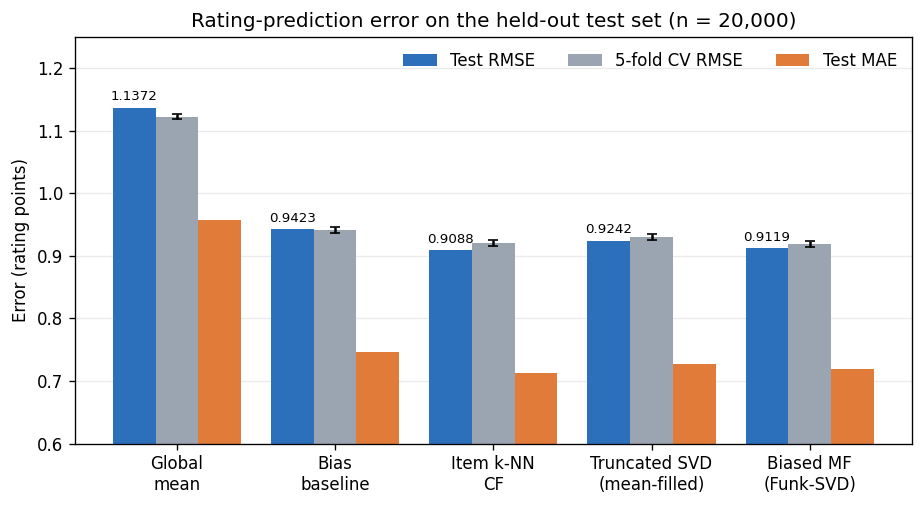

In [42]:
fig, ax = plt.subplots(figsize=(9, 4.4))
names = list(results)
labels = ["Global\nmean", "Bias\nbaseline", "Item k-NN\nCF",
          "Truncated SVD\n(mean-filled)", "Biased MF\n(Funk-SVD)"]
x = np.arange(len(names))

test_rmse = [results[n]["RMSE"] for n in names]
test_mae = [results[n]["MAE"] for n in names]
cv_mean = [float(np.mean(cv_scores[n])) for n in names]
cv_std = [float(np.std(cv_scores[n])) for n in names]

ax.bar(x - 0.27, test_rmse, 0.27, label="Test RMSE", color=BLUE)
ax.bar(x, cv_mean, 0.27, yerr=cv_std, capsize=3,
       label="5-fold CV RMSE", color=GREY)
ax.bar(x + 0.27, test_mae, 0.27, label="Test MAE", color=ORANGE)
for xi, v in zip(x - 0.27, test_rmse):
    ax.text(xi, v + 0.012, f"{v:.4f}", ha="center", fontsize=8)

ax.set(xticks=x, ylim=(0.6, 1.25), ylabel="Error (rating points)",
       title=f"Rating-prediction error on the held-out test set "
             f"(n = {len(test_idx):,})")
ax.set_xticklabels(labels)
ax.legend(frameon=False, ncol=3, loc="upper right")
ax.grid(axis="y", alpha=.25)
ax.set_axisbelow(True)
fig.savefig(os.path.join(IMG_DIR, "model_comparison.png"))
plt.show()

## § 12. Where the error actually lives

A single RMSE is an average over a very uneven population. Before trusting the number, it is
worth asking *who* the model is wrong about, a question that turns out to be as much an
ethical one as a technical one.

In [43]:
best_pred = predictions[best_model]
abs_err = np.abs(r_test - best_pred)
sq_err = (r_test - best_pred) ** 2

train_count_u = np.bincount(u_train, minlength=n_users)
train_count_i = np.bincount(i_train, minlength=n_items)


def slice_report(masks, labels, title):
    rows = []
    for mask, label in zip(masks, labels):
        if mask.sum() == 0:
            continue
        rows.append({
            "group": label,
            "test ratings": int(mask.sum()),
            "RMSE": round(float(np.sqrt(sq_err[mask].mean())), 4),
            "MAE": round(float(abs_err[mask].mean()), 4),
        })
    out = pd.DataFrame(rows)
    print(title)
    display(out)
    return out


q_user = np.quantile(train_count_u[train_count_u > 0], [.2, .4, .6, .8])
user_bin = np.digitize(train_count_u[u_test], q_user)
by_activity = slice_report(
    [user_bin == b for b in range(5)],
    ["Q1 least active", "Q2", "Q3", "Q4", "Q5 most active"],
    f"RMSE by how much the user rated during training ({best_model})"
)

q_item = np.quantile(train_count_i[train_count_i > 0], [.2, .4, .6, .8])
item_bin = np.digitize(train_count_i[i_test], q_item)
by_popularity = slice_report(
    [item_bin == b for b in range(5)],
    ["Q1 rarest", "Q2", "Q3", "Q4", "Q5 blockbusters"],
    f"RMSE by how often the movie was rated during training ({best_model})"
)

RMSE by how much the user rated during training (Item-based k-NN CF)


,group,test ratings,RMSE,MAE
0,Q1 least active,871,1.0056,0.7809
1,Q2,1433,0.9773,0.7698
2,Q3,2429,0.9238,0.7209
3,Q4,4959,0.9102,0.7172
4,Q5 most active,10308,0.8857,0.6949


RMSE by how often the movie was rated during training (Item-based k-NN CF)


,group,test ratings,RMSE,MAE
0,Q1 rarest,183,1.1539,0.8991
1,Q2,657,1.0404,0.8368
2,Q3,1992,0.9895,0.7849
3,Q4,4464,0.9156,0.7225
4,Q5 blockbusters,12704,0.8815,0.6888


In [44]:
# MovieLens ships self-reported demographics; they are used here only to audit
# the model for uneven performance, never as model inputs.
user_info = pd.read_csv(
    os.path.join(DATA_DIR, "u.user"),
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip"]
)

gender = user_info.set_index("user_id")["gender"].reindex(
    np.arange(1, n_users + 1)).to_numpy()
age = user_info.set_index("user_id")["age"].reindex(
    np.arange(1, n_users + 1)).to_numpy()

by_gender = slice_report(
    [gender[u_test] == "M", gender[u_test] == "F"],
    ["Male users", "Female users"],
    "RMSE by self-reported gender"
)

age_bin = np.digitize(age[u_test], [25, 35, 50])
by_age = slice_report(
    [age_bin == b for b in range(4)],
    ["under 25", "25-34", "35-49", "50 and over"],
    "RMSE by age band"
)

RMSE by self-reported gender


,group,test ratings,RMSE,MAE
0,Male users,14852,0.8865,0.6954
1,Female users,5148,0.9703,0.7625


RMSE by age band


,group,test ratings,RMSE,MAE
0,under 25,5312,0.9307,0.7288
1,25-34,7086,0.9199,0.7232
2,35-49,5296,0.8943,0.7027
3,50 and over,2306,0.8547,0.6662


In [45]:
# how does the model behave across the rating scale itself?
rows = []
for value in [1.0, 2.0, 3.0, 4.0, 5.0]:
    mask = r_test == value
    rows.append({
        "true rating": int(value),
        "test ratings": int(mask.sum()),
        "RMSE": round(float(np.sqrt(sq_err[mask].mean())), 4),
        "mean prediction": round(float(best_pred[mask].mean()), 4),
    })
by_rating = pd.DataFrame(rows)
print("Prediction behavior across the rating scale")
display(by_rating)
print("The model regresses toward the mean: it under-predicts 5s and")
print("over-predicts 1s, which is what squared-error training rewards.")

Prediction behavior across the rating scale


,true rating,test ratings,RMSE,mean prediction
0,1,1247,1.8051,2.6481
1,2,2313,1.2014,3.0389
2,3,5269,0.6502,3.3567
3,4,6780,0.5617,3.7223
4,5,4391,1.0400,4.0878


The model regresses toward the mean: it under-predicts 5s and
over-predicts 1s, which is what squared-error training rewards.


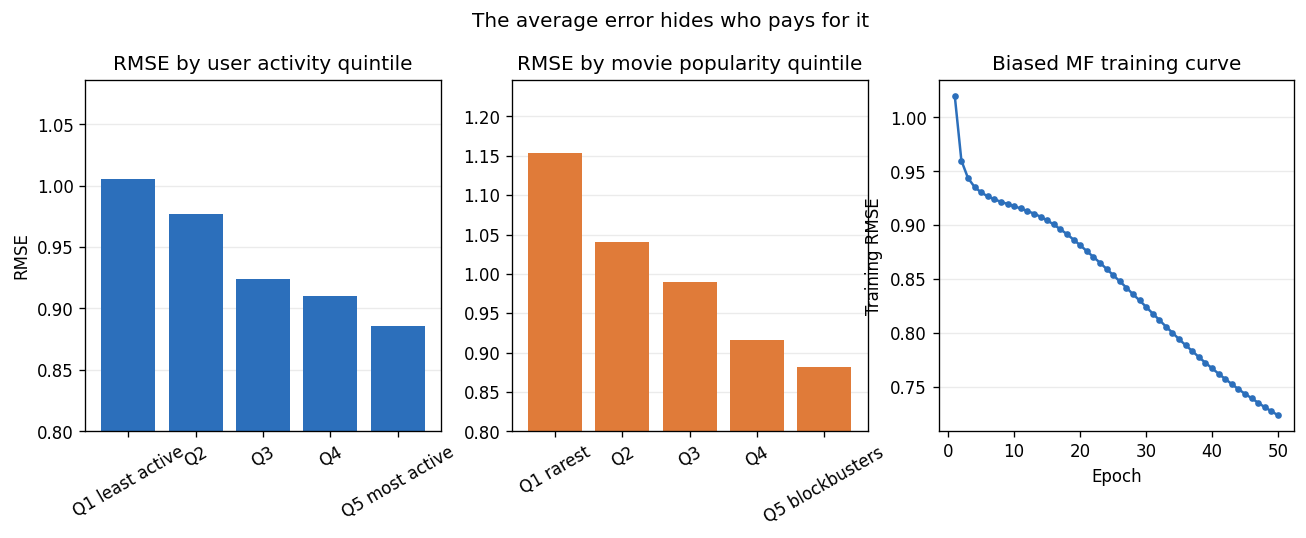

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

ax[0].bar(by_activity["group"], by_activity["RMSE"], color=BLUE)
ax[0].set(title="RMSE by user activity quintile", ylabel="RMSE",
          ylim=(0.8, by_activity["RMSE"].max() * 1.08))
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(by_popularity["group"], by_popularity["RMSE"], color=ORANGE)
ax[1].set(title="RMSE by movie popularity quintile",
          ylim=(0.8, by_popularity["RMSE"].max() * 1.08))
ax[1].tick_params(axis="x", rotation=30)

ax[2].plot(range(1, len(mf.history_) + 1), mf.history_,
           color=BLUE, marker="o", ms=3)
ax[2].set(title="Biased MF training curve", xlabel="Epoch",
          ylabel="Training RMSE")

for a in ax:
    a.grid(axis="y", alpha=.25)
    a.set_axisbelow(True)

fig.suptitle("The average error hides who pays for it", y=1.03)
fig.savefig(os.path.join(IMG_DIR, "error_structure.png"))
plt.show()

## § 13. From predicted ratings to an actual recommendation list

RMSE answers "how close are the predictions?" The business asked a different question: "are
the ten titles on the home screen any good?" Those are not the same question, and this
section measures the gap.

For each user we rank every movie they did **not** rate during training, keep the top ten,
and count a hit when the user gave that movie 4 or 5 in the held-out data. A
**most-popular** list, meaning the same ten blockbusters for everyone with no personalization
at all, is included as a control, because it is what a business gets for free.

In [47]:
def top_n(scores, seen_mask, n=10):
    """Rank unseen movies for every user and keep the best n."""
    s = scores.copy()
    s[seen_mask.astype(bool)] = -np.inf      # never re-recommend a rated movie
    idx = np.argpartition(-s, n, axis=1)[:, :n]
    rows = np.arange(s.shape[0])[:, None]
    order = np.argsort(-s[rows, idx], axis=1)
    return idx[rows, order]


def precision_recall_at_n(recs, relevant, n=10):
    precisions, recalls = [], []
    for user in range(recs.shape[0]):
        truth = relevant.get(user)
        if not truth:
            continue
        hits = len(set(recs[user, :n].tolist()) & truth)
        precisions.append(hits / n)
        recalls.append(hits / len(truth))
    return float(np.mean(precisions)), float(np.mean(recalls)), len(precisions)


seen = np.zeros((n_users, n_items))
seen[u_train, i_train] = 1

relevant = {}
for uu, ii, rr in zip(u_test, i_test, r_test):
    if rr >= 4:
        relevant.setdefault(uu, set()).add(ii)

# "long tail" = the 80% of the catalog that is least often rated
tail_cut = np.quantile(train_count_i[train_count_i > 0], 0.8)
is_long_tail = train_count_i < tail_cut

candidates = {
    "Bias baseline": clip(mu + b_u[:, None] + b_i[None, :]),
    "Biased MF (Funk-SVD)": mf.score_all(),
}

rows = []
for name, scores in candidates.items():
    recs = top_n(scores, seen, 10)
    p10, r10, evaluated = precision_recall_at_n(recs, relevant, 10)
    rows.append({
        "model": name,
        "precision@10": round(p10, 4),
        "recall@10": round(r10, 4),
        "distinct titles recommended": int(len(np.unique(recs))),
        "catalog coverage": f"{len(np.unique(recs)) / n_items:.2%}",
        "long-tail share of slots": f"{is_long_tail[recs].mean():.2%}",
    })

# non-personalized control: the ten most-rated movies, for everyone
popular = np.argsort(-train_count_i)[:10]
pop_recs = np.tile(popular, (n_users, 1))
p10, r10, evaluated = precision_recall_at_n(pop_recs, relevant, 10)
rows.append({
    "model": "Most-popular (no personalization)",
    "precision@10": round(p10, 4),
    "recall@10": round(r10, 4),
    "distinct titles recommended": 10,
    "catalog coverage": f"{10 / n_items:.2%}",
    "long-tail share of slots": f"{is_long_tail[pop_recs].mean():.2%}",
})

print(f"Top-10 quality, evaluated on the {evaluated} users who have at least")
print("one held-out rating of 4 or more\n")
display(pd.DataFrame(rows))

Top-10 quality, evaluated on the 932 users who have at least
one held-out rating of 4 or more



,model,precision@10,recall@10,distinct titles recommended,catalog coverage,long-tail share of slots
0,Bias baseline,0.0535,0.0398,112,6.66%,25.46%
1,Biased MF (Funk-SVD),0.0574,0.0438,242,14.39%,47.64%
2,Most-popular (no personalization),0.0695,0.0973,10,0.59%,0.00%


In [48]:
# what does the model actually put in front of someone?
title_of = movies_clean.set_index("item_id")["title"]
mf_recs = top_n(mf.score_all(), seen, 10)

for example_user in [0, 405]:
    print(f"\nTop 10 for user {example_user + 1} "
          f"({train_count_u[example_user]} ratings in training):")
    for rank, movie in enumerate(mf_recs[example_user], 1):
        print(f"  {rank:2d}. {title_of.get(movie + 1):<45} "
              f"({train_count_i[movie]:>3} ratings in training)")


Top 10 for user 1 (218 ratings in training):
   1. Pather Panchali (1955)                        (  8 ratings in training)
   2. Close Shave, A (1995)                         ( 83 ratings in training)
   3. Lawrence of Arabia (1962)                     (142 ratings in training)
   4. Ran (1985)                                    ( 53 ratings in training)
   5. Wallace & Gromit: The Best of Aardman Animation (1996) ( 52 ratings in training)
   6. One Flew Over the Cuckoo's Nest (1975)        (205 ratings in training)
   7. Hoop Dreams (1994)                            ( 90 ratings in training)
   8. Saint of Fort Washington, The (1993)          (  2 ratings in training)
   9. Wings of Desire (1987)                        ( 50 ratings in training)
  10. Third Man, The (1949)                         ( 65 ratings in training)

Top 10 for user 406 (274 ratings in training):
   1. Pather Panchali (1955)                        (  8 ratings in training)
   2. Wrong Trousers, The (1993)       

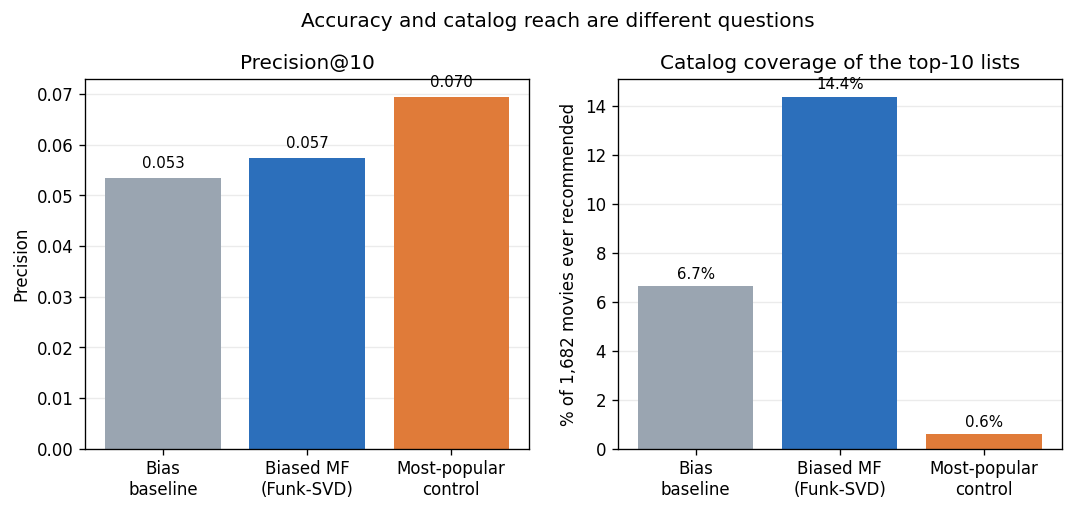

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
table = pd.DataFrame(rows)
labels = ["Bias\nbaseline", "Biased MF\n(Funk-SVD)", "Most-popular\ncontrol"]
colours = [GREY, BLUE, ORANGE]

ax[0].bar(labels, table["precision@10"], color=colours)
for xi, v in enumerate(table["precision@10"]):
    ax[0].text(xi, v + .002, f"{v:.3f}", ha="center", fontsize=9)
ax[0].set(title="Precision@10", ylabel="Precision")

coverage = [float(c.rstrip("%")) for c in table["catalog coverage"]]
ax[1].bar(labels, coverage, color=colours)
for xi, v in enumerate(coverage):
    ax[1].text(xi, v + .3, f"{v:.1f}%", ha="center", fontsize=9)
ax[1].set(title="Catalog coverage of the top-10 lists",
          ylabel=f"% of {n_items:,} movies ever recommended")

for a in ax:
    a.grid(axis="y", alpha=.25)
    a.set_axisbelow(True)

fig.suptitle("Accuracy and catalog reach are different questions", y=1.02)
fig.savefig(os.path.join(IMG_DIR, "recommendation_quality.png"))
plt.show()

## § 14. Ethical evaluation

The measurements above are not only performance numbers; several of them are the evidence
for the ethical risks this system would carry into production.

**Unequal service quality.** § 12 shows the error is not spread evenly. Users with the fewest
ratings and movies with the fewest ratings are predicted worst, which means the model serves
new and casual subscribers least well, exactly the people most likely to cancel, while
performing best for the power users it needs to convince least. Because RMSE is an average
weighted by rating volume, the heaviest users dominate the headline figure and make this
disparity invisible unless it is deliberately broken out.

**Popularity bias and the long tail.** § 13 quantifies how much of the catalog the
recommender ever reaches. A model can score well on accuracy while recommending a narrow band
of already-popular titles, which starves the niche catalog the business paid to license and
narrows what subscribers are ever exposed to. Accuracy alone would never surface this;
coverage does.

**Feedback loops.** Anything the model recommends gets watched and rated more, which makes it
look even more popular in the next training round. Left unmonitored, a recommender does not
merely observe taste, it manufactures it. Any production version needs a share of exploratory
or diversified slots and continuous monitoring of coverage over time, not a one-off check.

**Demographic performance.** The gender and age slices in § 12 are an audit, not a feature.
The demographics are never given to the model, but a model can still perform unevenly across
groups simply because one group is better represented in the training data. Measuring it is
the only way to know, and the group under-represented in MovieLens is small enough that its
slice deserves reporting with that caveat attached.

**Privacy.** A rating history is personal data. The latent factors learned in § 9.4 are a
compressed model of an individual's taste and can be re-identifying when combined with a
handful of publicly known preferences, the concern demonstrated on the Netflix Prize dataset
by Narayanan and Shmatikov (2008). MovieLens is released for research with that understood;
an operational system built on real subscribers would need consent, retention limits, and a
genuine route to deletion.

**Cold start.** The model has nothing to say about a movie it has never seen, and § 8 counts
exactly how many test cases that describes. A production system must degrade honestly to
non-personalized or content-based fallbacks rather than emit a confident-looking number
drawn from nothing.

## § 15. Conclusion and next steps

This is an initial model, and it is deliberately scoped as one. The comparison establishes
which family of approaches is worth pursuing and sets an honest baseline for anything that
follows.

The clearest direction for the next iteration is to stop optimizing RMSE alone. § 13 shows
that ranking quality and catalog reach are separate axes that squared error does not
capture, so the next round should train against a ranking objective directly. Beyond that:
implicit signals (what was watched, not merely what was rated) carry far more data than the
explicit ratings; movie genres and the timestamps already in the dataset would give a
content-based fallback for cold-start titles and a way to model taste drift; and a hybrid of
the neighborhood and latent-factor models typically beats either alone. Each of those is a
larger piece of work than this project's brief, and each is better started from a measured
baseline than from a guess.

## References

- Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets: History and context.
  *ACM Transactions on Interactive Intelligent Systems, 5*(4), 1–19.
- Koren, Y. (2010). Factor in the neighbors: Scalable and accurate collaborative filtering.
  *ACM Transactions on Knowledge Discovery from Data, 4*(1), 1–24.
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender
  systems. *Computer, 42*(8), 30–37.
- Narayanan, A., & Shmatikov, V. (2008). Robust de-anonymization of large sparse datasets.
  *2008 IEEE Symposium on Security and Privacy*, 111–125.
- Sarwar, B., Karypis, G., Konstan, J., & Riedl, J. (2001). Item-based collaborative filtering
  recommendation algorithms. *Proceedings of the 10th International Conference on World Wide
  Web*, 285–295.